# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure

| Field | Your answer                                                                                                                                                                                                                                                                                                                      |
|-------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool | OpenCode Desktop+ GPT-5.6 Sol                                                                                                                                                                                                                                                                                                    |
| Used for | Explaining the assignment requirements, understanding the MNIST data preparation and Keras model structure, reviewing the baseline and dropout code, interpreting the training and validation curves, checking the confusion-matrix method.                                                                                      |
| Verified  | I verified the final notebook by restarting the kernel and running all cells in order. I confirmed that both models completed all epochs without errors, checked that the reported test accuracies came from model.evaluate(), inspected the training and validation curves, verified the confusion matrix and worst digit pair. |
| Not used for | The AI tool was not used to run the experiments, generate or alter numerical results, or make the final conclusions without verification. All reported accuracies and confusion-matrix results came directly from my executed notebook, and I reviewed the final code and explanations myself.                                   |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

## 1. Load MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10
print(x_train_flat.shape, y_train.shape)

(60000, 784) (60000,)


## 2. Validation split

In [3]:
val_samples = 10000
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [4]:
def build_model(use_dropout=False, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Train baseline (no dropout)

In [5]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9272 - loss: 0.2486 - val_accuracy: 0.9612 - val_loss: 0.1259
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9722 - loss: 0.0908 - val_accuracy: 0.9692 - val_loss: 0.1032
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9822 - loss: 0.0572 - val_accuracy: 0.9757 - val_loss: 0.0798
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9880 - loss: 0.0386 - val_accuracy: 0.9740 - val_loss: 0.0859
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.9741 - val_loss: 0.0855
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9926 - loss: 0.0214 - val_accuracy: 0.9772 - val_loss: 0.0866
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.9803 - val_loss: 0.0789
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9951 - loss: 0.0149 - val_accuracy: 0.

## 5. Train with dropout

In [6]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9168 - loss: 0.2766 - val_accuracy: 0.9631 - val_loss: 0.1200
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9683 - loss: 0.1042 - val_accuracy: 0.9722 - val_loss: 0.0906
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9792 - loss: 0.0674 - val_accuracy: 0.9750 - val_loss: 0.0804
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.9751 - val_loss: 0.0858
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0361 - val_accuracy: 0.9761 - val_loss: 0.0819
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0283 - val_accuracy: 0.9789 - val_loss: 0.0740
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0243 - val_accuracy: 0.9770 - val_loss: 0.0732
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9939 - loss: 0.0187 - val_accuracy: 0.

## 6. Compare learning curves

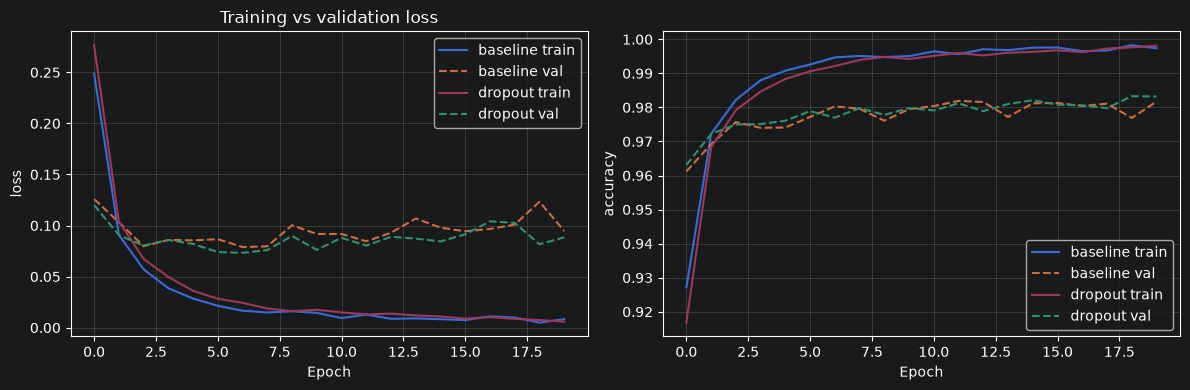

In [7]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # accuracy panel
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

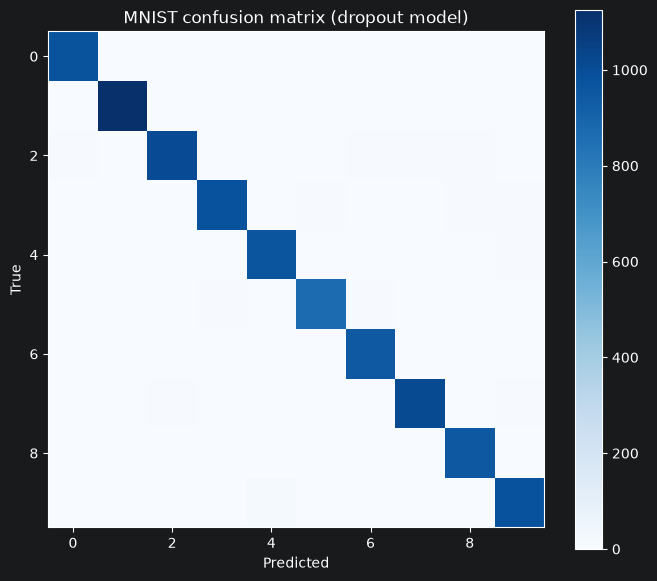

Worst confused pair (Moodle a2_worst_pair): 9-4 (14 errors)


In [8]:
y_pred = np.argmax(model_dropout.predict(x_test_flat, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output

MNIST labels remain integer class indices from 0 to 9; one-hot labels instead use ten-element vectors with 1 for the correct digit and 0 for every other class.
The loss computes the negative logarithm of the softmax probability assigned to the correct integer label for each MNIST image, then averages these values across the batch. A high probability for the correct digit produces a small loss, while a low probability produces a large loss, guiding the optimizer to improve the model’s predictions.
Softmax converts the model’s ten output scores into a probability distribution over digits 0–9, with the probabilities summing to one. Sparse categorical crossentropy uses the true integer label to select the corresponding probability and penalizes the model when that probability is low.